In [11]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os
import glob


# Target the Sharepoint Folder

In [21]:
# 1. Get the base user profile (handles Drew.Quinton vs any other user)
home = os.path.expanduser("~")

# 2. Define the potential OneDrive/SharePoint root folders
# Different machines might use "OneDrive - DOT OST" or just "OneDrive"
roots = [
    os.path.join(home, "OneDrive - DOT OST"),
    os.path.join(home, "OneDrive - USDOT"),
    os.path.join(home, "DOT"),
]

for root in roots:
    if os.path.exists(root):
        # 3. Use a "recursive glob" to find the specific target folder.
        # This looks for 'Daily Feed Pull' anywhere inside the OneDrive folder,
        # ignoring whatever renamed shortcut lies in between.
        search_pattern = os.path.join(root, "**", "Daily Feed Pull")
        matches = glob.glob(search_pattern, recursive=True)
        
        if matches:
            # Return the first match found
            daily_feed_pull_folder = Path(matches[0])
        else:
            from tkinter import filedialog, Tk
            root = Tk()
            root.withdraw() # Hide the tiny white window
            daily_feed_pull_folder = Path(filedialog.askdirectory(title="Please select the 'Daily Feed Pull' folder"))

# Create Dataframes

In [23]:
closure_file_list = [
    f for f in daily_feed_pull_folder.iterdir() 
    if f.is_file() and f.name.endswith('_Road_Closure_Feed.csv')
]

if closure_file_list:
    closures_df = pd.concat([pd.read_csv(f) for f in closure_file_list], ignore_index=True)
    print(f"Merged {len(closure_file_list)} Road Closure Feed files into 'closures_df'.")
else:
    print("No matching files found.")
    
alerts_file_list = [
    f for f in daily_feed_pull_folder.iterdir() 
    if f.is_file() and f.name.endswith('_alerts_feed.csv')
]

if alerts_file_list:
    alerts_df = pd.concat([pd.read_csv(f) for f in alerts_file_list], ignore_index=True)
    print(f"Merged {len(alerts_file_list)} Alerts Feed files in 'alerts_df'.")
else:
    print("No matching files found.")

Merged 41 Road Closure Feed files into 'closures_df'.
Merged 41 Alerts Feed files in 'alerts_df'.


# Closure Feed Analysis

### Number of Closures Over Time

In [24]:
closure_count_by_park = pd.pivot_table(
    closures_df,
    values='core_details.event_type',
    index = 'organization_name',
    columns='extraction_date',
    aggfunc='count'
)
closure_count_by_park = closure_count_by_park.fillna(0).astype(int)
closure_count_by_park

extraction_date,2026-03-13,2026-03-14,2026-03-15,2026-03-16,2026-03-17,2026-03-18,2026-03-19,2026-03-20,2026-03-21,2026-03-22,...,2026-04-15,2026-04-16,2026-04-17,2026-04-18,2026-04-19,2026-04-20,2026-04-21,2026-04-22,2026-04-23,2026-04-24
organization_name,,,,,,,,,,,,,,,,,,,,,
Acadia National Park,0,0,0,0,0,0,0,0,0,0,...,5,5,5,5,5,5,5,5,5,5
Black Canyon of the Gunnison National Park,8,8,8,0,8,8,8,8,8,8,...,4,4,4,4,4,4,4,4,4,4
Blue Ridge Parkway,20,20,20,20,70,70,70,72,72,72,...,16,0,0,0,0,0,0,0,0,0
Buffalo National River,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Canyonlands National Park,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
Crater Lake National Park,10,10,10,10,10,10,10,10,10,10,...,22,22,22,10,10,10,10,10,10,10
Curecanti National Recreation Area,2,2,2,0,2,2,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
Delaware Water Gap,18,18,18,0,18,18,18,18,18,18,...,12,10,10,10,10,10,10,10,14,14
Fort Dupont Park,0,0,0,0,20,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
count = closures_df['extraction_date'].nunique()
print(f'{count} days of daily pulls')

41 days of daily pulls


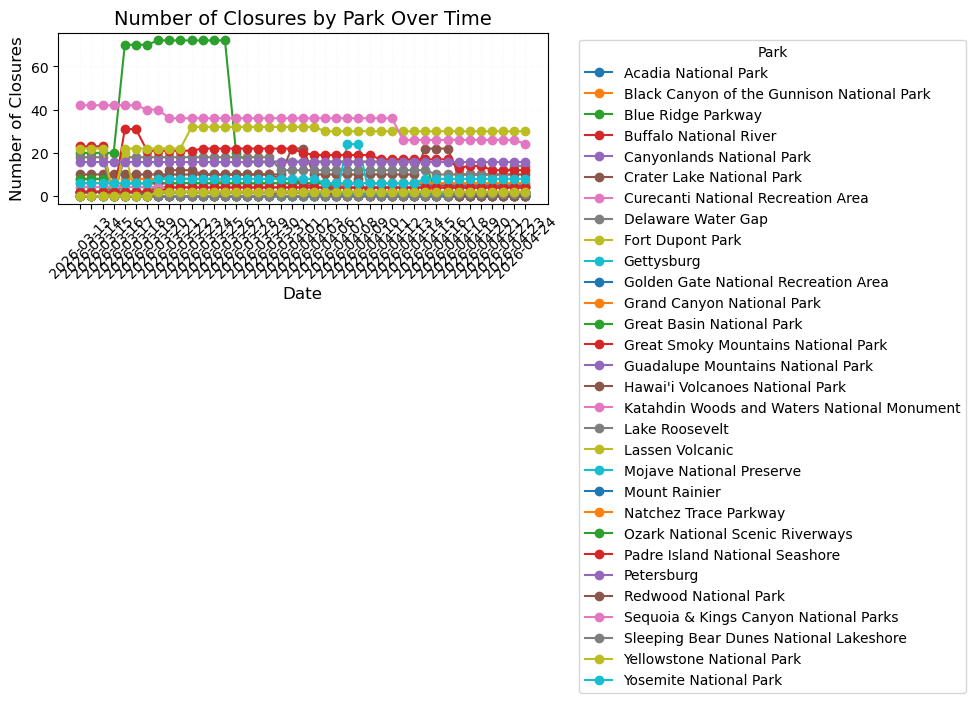

In [26]:
df_plot = closure_count_by_park.T
plt.figure(figsize=(10, 5))

for column in df_plot.columns:
    plt.plot(df_plot.index, df_plot[column], marker='o', label=column)

plt.title("Number of Closures by Park Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.xticks(rotation=45)
plt.ylabel("Number of Closures", fontsize=12)
plt.legend(title="Park", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=.06)
    
plt.tight_layout()

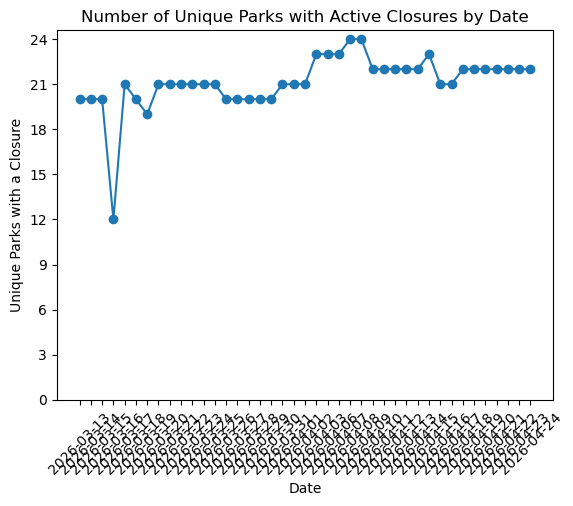

In [27]:
unique_parks_per_day = closures_df.groupby('extraction_date')['organization_name'].nunique()
unique_parks_per_day = pd.DataFrame(unique_parks_per_day)
unique_parks_per_day = unique_parks_per_day.reset_index()

plt.plot(unique_parks_per_day['extraction_date'], unique_parks_per_day['organization_name'], marker='o', linestyle='-')

plt.xlabel('Date')
plt.ylabel('Unique Parks with a Closure')
plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True)) # Force Y-axis to only show whole numbers (integers)
plt.title('Number of Unique Parks with Active Closures by Date')
plt.xticks(rotation=45)

plt.show()

# Alerts Feed Analysis

### Number of Alerts Over Time

In [28]:
alerts_count_by_park = pd.pivot_table(
    alerts_df,
    values='id',
    index = 'parkCode',
    columns='extraction_date',
    aggfunc='count'
)
alerts_count_by_park = alerts_count_by_park.fillna(0).astype(int)
alerts_count_by_park

extraction_date,2026-03-13,2026-03-14,2026-03-15,2026-03-16,2026-03-17,2026-03-18,2026-03-19,2026-03-20,2026-03-21,2026-03-22,...,2026-04-15,2026-04-16,2026-04-17,2026-04-18,2026-04-19,2026-04-20,2026-04-21,2026-04-22,2026-04-23,2026-04-24
parkCode,,,,,,,,,,,,,,,,,,,,,
abli,0,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
acad,1,1,1,1,2,2,3,3,3,3,...,4,4,4,4,4,4,4,4,4,4
adam,3,3,3,3,3,3,3,3,3,3,...,2,2,2,2,2,2,2,2,2,2
afbg,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
agfo,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yell,4,4,4,3,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
york,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
yose,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
